In [129]:
import torch                          # import torch library
import torch.nn as nn                 # import nn module for creating layers, models and functions
import numpy as np                    # import numpy library
from torch.autograd import Variable   # variable from numpy to torch
import matplotlib.pyplot as plt       # import pyplot library

In [130]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu") # set GPU as processing device
print(device)

cuda:0


In [131]:
epochs = 2000  # number of training epochs
col_p  = 2000  # number of collocation points
hid_n  = 80   # number of neurons on hidden layers

E = 2.1e10            # Pa  (Young Modulus)
I = (.10*.15**3/12)   # m^4 (Beam inertia)
L = 3                 # m   (Beam length)
q_0 = 100e3           # N/m (Punctual load q)

class NN(nn.Module):                               # create neural network
    def __init__(self):                            # initialize 
        super(NN, self).__init__()                 # input layer, 1 input - x
        self.hidden_lay1 = nn.Linear(1,hid_n)      # first hidden layer, 150 neurons
        self.hidden_lay2 = nn.Linear(hid_n,hid_n)  # seconfd hidden layer, 150 neurons
        self.hidden_lay3 = nn.Linear(hid_n,hid_n)  # seconfd hidden layer, 150 neurons
        self.output_lay  = nn.Linear(hid_n,1)      # output layer, 1 output - v(x)
        
    def forward(self,x):
        inputs   = x                     
        lay1_out = torch.tanh(self.hidden_lay1(inputs))   # sigmoid activation function in hidden layer
        lay2_out = torch.tanh(self.hidden_lay2(lay1_out)) # sigmoid activation function in hidden layer
        lay3_out = torch.tanh(self.hidden_lay3(lay2_out)) # sigmoid activation function in hidden layer
        output   = self.output_lay(lay3_out)              # for regression, no activation is used in output layer
        return output

In [132]:
### (2) Model
NN = NN()
NN = NN.to(device)                                       # transfer net to GPU for processing
mse_cost_function = torch.nn.MSELoss()                   # mean squared error as loss function
optimizer = torch.optim.Adam(NN.parameters(), lr=0.002)  # Adam optimizer for parameter updating

In [133]:
## PDE as loss function.
def f(x,NN):
    v = NN(x) # the dependent variable u is given by the network based on independent variable x
    ## Based on our f = E*I*d4v/dx4 - (q_0/L)*x, we need d4v/dx4
    v_x  = torch.autograd.grad(v.sum(),x, create_graph=True)[0]    # dv/dx
    v_x2 = torch.autograd.grad(v_x.sum(),x,create_graph=True)[0]   # d2v/dx2
    v_x3 = torch.autograd.grad(v_x2.sum(),x,create_graph=True)[0]  # d3v/dx3
    v_x4 = torch.autograd.grad(v_x3.sum(),x,create_graph=True)[0]  # d4v/dx4
    pde  = E*I*v_x4 + q_0*x/L                        
    return pde

In [134]:
## Data from Boundary Conditions
## BC gives us datapoints for training
## We will find out v(x) for x in range [0,L]

#################################### 1. x=0, v(0)=0 ####################################
x_bc1  = np.zeros((col_p,1))         # Take say 200 random numbers of (x,v)
v_bc1  = np.zeros((col_p,1))         # Compute v based on BC

#################################### 2. x=0, dv/dx=0 ###################################
x_bc2   = np.zeros((col_p,1))        # Take say 200 random numbers of (x,v)
v_x_bc2 = np.zeros((col_p,1))        # Compute dv/dx based on BC

#################################### 3. x=L, EI*d3v/dx3=0 ###############################
x_bc3    = L*np.ones((col_p,1))      # Take say 200 random numbers of (x,v)
v_x3_bc3 = np.zeros((col_p,1))       # Compute d3v/dx3 based on BC

#################################### 4. x=L, EI*d2v/dx2=0 ##############################
x_bc4    = L*np.ones((col_p,1))      # Take say 200 random numbers of (x,v)
v_x2_bc4 = np.zeros((col_p,1))       # Compute d2v/dx2 based on BC

In [135]:
### (3) Training / Fitting
Loss_track = []                    # Creating empty list for gathering loss values

for epoch in range(epochs):
    optimizer.zero_grad() # to make the gradients zero
    
    # Loss based on boundary conditions
    # BC 1.
    pt_x_bc1   = Variable(torch.from_numpy(x_bc1).float(), requires_grad=False).to(device)
    pt_v_bc1   = Variable(torch.from_numpy(v_bc1).float(), requires_grad=False).to(device)
    
    NN_bc1_out = NN(pt_x_bc1) # output NN(x) --> v
    mse_u1     = mse_cost_function(NN_bc1_out, pt_v_bc1)
    
    # BC 2.
    pt_x_bc2   = Variable(torch.from_numpy(x_bc2).float(), requires_grad=True).to(device)
    pt_v_x_bc2 = Variable(torch.from_numpy(v_x_bc2).float(), requires_grad=False).to(device)
    
    NN_bc2_out = NN(pt_x_bc2) # output NN(x) --> v
    dv_x_bc2   = torch.autograd.grad(NN_bc2_out.sum(),pt_x_bc2,create_graph=True)[0]
    mse_u2     = mse_cost_function(dv_x_bc2, pt_v_x_bc2)
    
    # BC 3.
    pt_x_bc3   = Variable(torch.from_numpy(x_bc3).float(), requires_grad=True).to(device)
    pt_v_x3_bc3= Variable(torch.from_numpy(v_x3_bc3).float(), requires_grad=False).to(device)
    
    NN_bc3_out = NN(pt_x_bc3) # output NN(x) --> v
    dv_x_bc3   = torch.autograd.grad(NN_bc3_out.sum(),pt_x_bc3,create_graph=True)[0]
    dv_x2_bc3  = torch.autograd.grad(dv_x_bc3.sum(),pt_x_bc3,create_graph=True)[0]
    dv_x3_bc3  = torch.autograd.grad(dv_x2_bc3.sum(),pt_x_bc3,create_graph=True)[0]
    mse_u3     = mse_cost_function(dv_x3_bc3, pt_v_x3_bc3)
        
    # BC 4.
    pt_x_bc4   = Variable(torch.from_numpy(x_bc4).float(), requires_grad=True).to(device)
    pt_v_x2_bc4 = Variable(torch.from_numpy(v_x2_bc4).float(), requires_grad=False).to(device)
    
    NN_bc4_out = NN(pt_x_bc4) # output NN(x) --> v
    dv_x_bc4   = torch.autograd.grad(NN_bc4_out.sum(),pt_x_bc4,create_graph=True)[0]
    dv_x2_bc4  = torch.autograd.grad(dv_x_bc4.sum(),pt_x_bc4,create_graph=True)[0]
    mse_u4     = mse_cost_function(dv_x2_bc4, pt_v_x2_bc4)
    
    # Loss based on PDE
    x_col        = np.random.uniform(low=0.0, high=L, size=(col_p,1))
    all_zeros    = np.zeros((col_p,1))
    pt_x_col     = Variable(torch.from_numpy(x_col).float(), requires_grad=True).to(device)
    pt_all_zeros = Variable(torch.from_numpy(all_zeros).float(), requires_grad=False).to(device)
    
    f_out        = f(pt_x_col,NN)                # output of f(x)
    mse_f        = mse_cost_function(f_out, pt_all_zeros)
    
    # Combining the loss functions
    loss = mse_u1 + mse_u2 + mse_u3 + mse_u4 + mse_f
    
    loss.backward()  # This is for computing gradients using backward propagation
    optimizer.step() # This is equivalent to: theta_new = theta_old - alpha * derivative of J w.r.t theta
    
    loss_np = loss.data.cpu().numpy()          # Torch tensors to Numpy
    Loss_track = np.append(Loss_track,loss_np) # Tracking loss values and creating a list
    
    with torch.autograd.no_grad():
        if epoch % 10 == 0: print(epoch,"Traning Loss:",loss.data) # Print loss every 10 epochs

0 Traning Loss: tensor(2.4027e+09, device='cuda:0')
10 Traning Loss: tensor(4.0373e+09, device='cuda:0')
20 Traning Loss: tensor(1.1238e+09, device='cuda:0')
30 Traning Loss: tensor(7.6484e+08, device='cuda:0')
40 Traning Loss: tensor(3.8301e+08, device='cuda:0')
50 Traning Loss: tensor(2.4744e+08, device='cuda:0')
60 Traning Loss: tensor(1.5819e+08, device='cuda:0')
70 Traning Loss: tensor(1.3202e+08, device='cuda:0')
80 Traning Loss: tensor(1.1779e+08, device='cuda:0')
90 Traning Loss: tensor(95044520., device='cuda:0')
100 Traning Loss: tensor(83684712., device='cuda:0')
110 Traning Loss: tensor(68814600., device='cuda:0')
120 Traning Loss: tensor(60350720., device='cuda:0')
130 Traning Loss: tensor(51392432., device='cuda:0')
140 Traning Loss: tensor(41663368., device='cuda:0')
150 Traning Loss: tensor(33853688., device='cuda:0')
160 Traning Loss: tensor(27830586., device='cuda:0')
170 Traning Loss: tensor(21121370., device='cuda:0')
180 Traning Loss: tensor(17076310., device='cuda

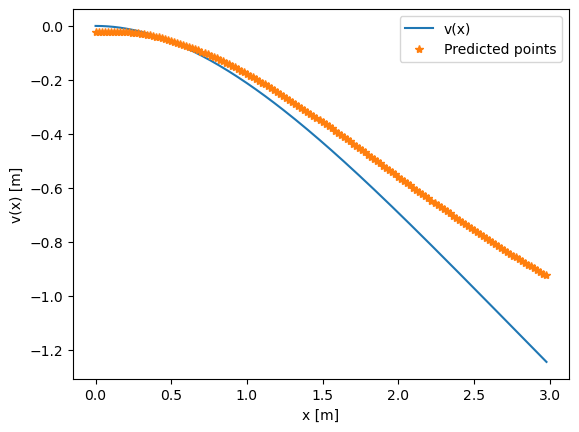

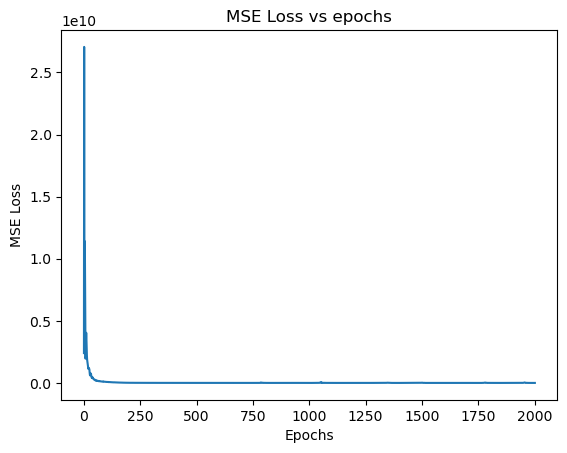

In [136]:
#### Plotting results ###

# Differential equation vs Predicted results
x = np.arange(0,L,0.02)
y = -q_0*(x**5)/(120*E*I*L)+q_0*L*(x**3)/(12*E*I)-q_0*(L**2)*(x**2)/(6*E*I)
x = x.reshape(-1,1)

pt_x = Variable(torch.from_numpy(x).float(), requires_grad=True).to(device)
pt_v = NN(pt_x)
v    = pt_v.data.cpu().numpy()

plt.plot(x,y)
plt.plot(x,v,'*')
plt.xlabel('x [m]')
plt.ylabel('v(x) [m]')
plt.legend(['v(x)','Predicted points'])
plt.show()

#Loss graphics
ep = np.linspace(1,epochs,epochs)
plt.plot(ep,Loss_track)
plt.title('MSE Loss vs epochs')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.show()